## Deep learning model pipeline requires two lib:
- tensors flow - manually codes which are lengthy and write every func manually. very old lib
- keras 2.o - it is built on top of tensor flow. requires less coding
- keras 3.0 - independent lib.

### 0 to 9 image classification

### Importing lib

In [1]:
import tensorflow as tf

In [2]:
import keras
import pandas as pd
import matplotlib.pyplot as plt

### Data Collection

In [3]:
pd.DataFrame(keras.datasets.mnist.load_data())

,0,1
0,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, ..."
1,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ..."


In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data() 

### Data Understanding

In [5]:
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [6]:
X_test.shape, y_test.shape

((10000, 28, 28), (10000,))

In [42]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [7]:
#An assert statement tests if a condition is true,
#raising an AssertionError to stop execution if it evaluates to false.
assert X_train.shape == (60000, 28, 28)
assert X_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,) 

### Data image understanding on how to look into images

In [8]:
X_train[1] #convert this to dataframe we need pandas

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [9]:
pd.DataFrame(X_train[1]) # we want o see the entire dataset on this x_train[1]

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,159,50,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,252,237,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,233,252,57,6,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,84,252,253,122,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,96,189,253,167,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,47,79,255,168,0,0,0,0,0,0


In [10]:
pd.set_option('display.max_columns',None)

In [11]:
pd.DataFrame(X_train[1]) # now u see the entire dataset and u can spot 0

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51,159,253,159,50,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,48,238,252,252,252,237,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,54,227,253,252,239,233,252,57,6,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,10,60,224,252,253,252,202,84,252,253,122,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,163,252,252,252,253,252,252,96,189,253,167,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,51,238,253,253,190,114,253,228,47,79,255,168,0,0,0,0,0,0


### lets see the image in colored formt using matplotlib plotly

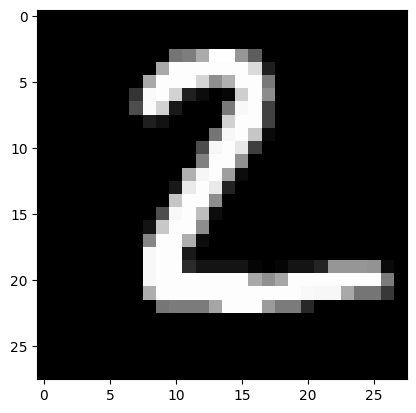

In [12]:
plt.imshow(X_test[1],cmap='grey')

### Data Preparation

#### we need to normalize the data for faster processtion so it the data ranges between 0 to 1. (find the max value, usually color ranges between 0 to 255. from this you got to know that the max value is 255.) 

In [13]:
X_train= X_train/255.0

In [14]:
X_test = X_test/255.0

In [15]:
#checking the max and min value
X_test.max(),X_test.min()

(np.float64(1.0), np.float64(0.0))

In [16]:
X_train.max(),X_train.min()

(np.float64(1.0), np.float64(0.0))

### Model Building

In [17]:
from keras.models import Sequential
from keras.layers import Flatten,Dense
import warnings
warnings.filterwarnings("ignore")

In [22]:
model = Sequential()
model.add(layer=Flatten(input_shape=(28,28)))
model.add(Dense(units=100,activation='relu'))
model.add(Dense(units=30,activation='relu'))

model.add(Dense(units=10,activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │           3,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81,840 (319.69 KB)

 Trainable params: 81,840 (319.69 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

### Model Training

In [24]:
model.fit(x=X_train,y=y_train,batch_size=32,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2564 - sparse_categorical_accuracy: 0.9255 - val_loss: 0.1357 - val_sparse_categorical_accuracy: 0.9576
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.1206 - sparse_categorical_accuracy: 0.9642 - val_loss: 0.1060 - val_sparse_categorical_accuracy: 0.9690
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0905 - sparse_categorical_accuracy: 0.9726 - val_loss: 0.0980 - val_sparse_categorical_accuracy: 0.9722
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0737 - sparse_categorical_accuracy: 0.9776 - val_loss: 0.0886 - val_sparse_categorical_accuracy: 0.9753
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0627 - sparse_categorical_accuracy: 0.9813 - val_loss: 0.0793 - val_sparse_categorical_accuracy: 0.9771
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0523 - sparse_categorical_accuracy: 0.9842 - val_loss: 0.0864 - val_sparse_categorical_accuracy:

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │           3,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 163,682 (639.39 KB)

 Trainable params: 81,840 (319.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,842 (319.70 KB)

### Model prediction 

In [27]:
y_pred =model.predict(X_test)`

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [43]:
y_test[67]

np.uint8(4)

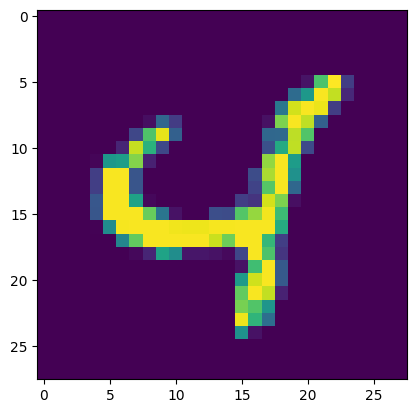

In [44]:
plt.imshow(X_test[67])

In [45]:
y_pred[67]

array([6.1230437e-19, 1.0001913e-14, 1.7551095e-10, 3.3502891e-13,
       1.0000000e+00, 4.5947200e-12, 1.1352725e-12, 6.5922413e-14,
       5.9817403e-15, 1.4947661e-08], dtype=float32)

In [33]:
import numpy as np

In [46]:
np.argmax(y_pred[67])

np.int64(4)

## Lets check with the outside data

### 1. take out the model intelligent file

In [47]:
model.save("Digits_finder.h5")

### 2. Load image

In [48]:
from PIL import Image #to load image we need this lib 

In [101]:
image_path = r"C:\Users\amrit\Documents\DataScienceLearning\Deep Learning\colorno3.jpg"
image_find = Image.open(image_path).convert(mode='L').resize(size=(28,28)) #convert the image to 28x28 and black and white.
image_find = np.array(image_find) #convert the image to array,why? because out model process the input in arrays.
pd.DataFrame(image_find)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255
1,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255
2,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255,255
3,255,255,255,255,255,255,255,255,255,255,255,255,249,230,215,216,229,248,255,255,255,255,255,255,255,255,255,255
4,255,255,255,255,255,255,255,255,255,249,245,212,143,100,83,82,84,111,176,246,255,255,255,255,255,255,255,255
5,255,255,255,255,255,255,255,245,230,232,217,112,75,68,67,60,54,51,56,124,239,255,255,255,255,255,255,255
6,255,255,255,255,255,255,242,219,219,225,132,77,74,68,62,58,56,56,52,49,136,253,255,255,255,255,255,255
7,255,255,255,255,255,252,217,209,212,173,84,77,74,64,67,68,69,58,56,51,60,209,255,255,255,255,255,255
8,255,255,255,255,255,241,196,197,201,140,75,78,67,57,46,54,74,101,63,52,43,144,255,255,255,255,255,255
9,255,255,255,255,255,231,177,178,180,131,84,76,63,53,29,25,48,117,82,49,42,106,255,255,255,255,255,255


In [102]:
from keras.models import load_model # lib to load the model

In [103]:
digits_brain=load_model("Digits_finder.h5") # create an obj of loaded model

In [107]:
def predictImage(image):
    image = image/255
    image=np.expand_dims(a=image,axis=0)
    predict_number = digits_brain.predict(image)
    return np.argmax(predict_number)

In [109]:
predictImage(image_find)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


np.int64(5)

### Why expand dimensions using `np.expand_dims`?

Keras models **always expect a batch of images** as input, never a single 2D image matrix.

---

#### 1. The Shape Conflict
When loading a custom image, its NumPy array shape is **`(28, 28)`** (2D array: $28 \text{ rows} \times 28 \text{ columns}$).

However, your model's input layer expects a shape of **`(batch_size, 28, 28)`**. 

Even when predicting on a single image, Keras requires the batch dimension to exist. Passing `(28, 28)` directly into `.predict()` causes TensorFlow to throw a `ValueError` because it received 2 dimensions instead of 3.

---

#### 2. What `np.expand_dims(image, axis=0)` does
It adds a new axis at position `0` (the start of the array):

* **Before:** `(28, 28)` $\rightarrow$ 2D array (single image)
* **After:** `(1, 28, 28)` $\rightarrow$ 3D array (batch containing 1 image)

Now the input matches the model's `(None, 784)` input structure, allowing `digits_brain.predict()` to run smoothly!

